# Projektaufgabe: Deskriptive Statistik und Visualisierungen

In [204]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

In [212]:
df = pd.read_csv("../data/Library_Usage.csv",low_memory=False, na_values="Null")
# drop missing values and sort by Age Range
df = df.dropna().sort_values('Age Range')

df.head()

,Patron Type Definition,Total Checkouts,Total Renewals,Age Range,Home Library Definition,Circulation Active Month,Circulation Active Year,Notice Preference Definition,Provided Email Address,Year Patron Registered,Within San Francisco County
377911,Juvenile,5,2,0 to 9 years,Ortega,May,2023.0,Phone,False,2023,True
368858,Juvenile,11,0,0 to 9 years,Excelsior,Mar,2024.0,Email,True,2021,True
368866,Juvenile,1,1,0 to 9 years,Excelsior,Jan,2022.0,Email,True,2021,True
377962,Juvenile,103,85,0 to 9 years,Ortega,Mar,2024.0,Email,True,2019,True
368868,Juvenile,7,5,0 to 9 years,Excelsior,Jul,2023.0,Email,True,2021,True


In [378]:
df.dtypes

Patron Type Definition           object
Total Checkouts                   int64
Total Renewals                    int64
Age Range                        object
Home Library Definition          object
Circulation Active Month         object
Circulation Active Year         float64
Notice Preference Definition     object
Provided Email Address             bool
Year Patron Registered            int64
Within San Francisco County      object
Age Category                     object
dtype: object

In [372]:
## FIND AND DELETE OUTLIERS

In [304]:
df['Patron Type Definition'].value_counts()

Patron Type Definition
Adult                  269567
Senior                  47074
Juvenile                41767
Teen                    34329
Welcome                  7703
Digital Access Card      3064
Teacher Card             2844
Visitor                   178
Retired Staff             137
At User Adult             123
Library By Mail           110
At User Senior             72
At User Teen                8
At User Welcome             8
At User Juvenile            5
Bibliocommons               3
Business                    1
Name: count, dtype: int64

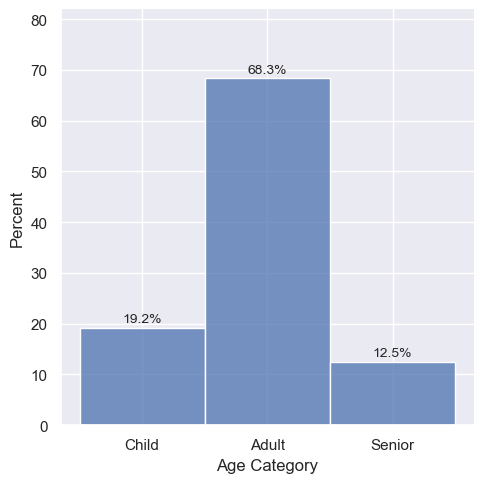

In [254]:
df_test['Age Category'] = df_test['Age Range']

age_mapping = {
        '0 to 9 years':'Child',
        '10 to 19 years':'Child',
        '20 to 24 years':'Adult',
        '25 to 34 years':'Adult',
        '35 to 44 years':'Adult',
        '45 to 54 years':'Adult',
        '55 to 59 years':'Adult',
        '60 to 64 years':'Adult',
        '65 to 74 years':'Senior',
        '75 years and over':'Senior'
    }

df_test['Age Category'] = df_test['Age Category'].replace(age_mapping)
fg = sns.displot(x='Age Category', data=df_test, stat='percent')

for ax in fg.axes.ravel():
    
    # add annotations
    for c in ax.containers:

        # custom label calculates percent and add an empty string so 0 value bars don't have a number
        labels = [f'{w:0.1f}%' if (w := v.get_height()) > 0 else '' for v in c]

        ax.bar_label(c, labels=labels, label_type='edge', fontsize=10, padding=2)
    
    ax.margins(y=0.2)

## Wie viele Senioren und Kinder sind Kunden der San Francisco Public Library?

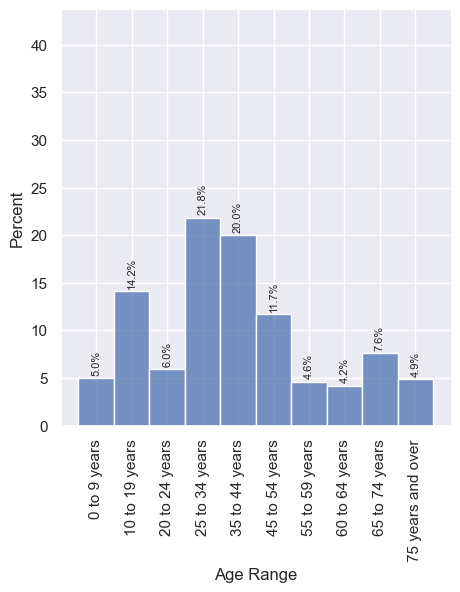

In [298]:
# Plot Age Range Distribution
fg = sns.displot(x='Age Range', data=df_cleaned, stat='percent')

for ax in fg.axes.ravel():
    
    # add annotations
    for c in ax.containers:

        # custom label calculates percent and add an empty string so 0 value bars don't have a number
        labels = [f'{w:0.1f}%' if (w := v.get_height()) > 0 else '' for v in c]

        ax.bar_label(c, labels=labels, label_type='edge', fontsize=8, rotation=90, padding=2)
    
    ax.margins(y=1)



fg.tick_params(axis='x', labelrotation=90)

In [294]:
df_test['Age Category'].value_counts()

Age Category
Adult     278108
Child      78063
Senior     50822
Name: count, dtype: int64

## Wie viele Nutzer möchten per Mail informiert werden?

In [274]:
df['Notice Preference Definition'].value_counts()

Notice Preference Definition
Email    372805
Phone     28888
Print      5300
Name: count, dtype: int64

In [266]:
df['Notice Preference Definition'].value_counts(normalize=True)

Notice Preference Definition
Email    0.915999
Phone    0.070979
Print    0.013022
Name: proportion, dtype: float64

<Axes: xlabel='Notice Preference Definition', ylabel='count'>

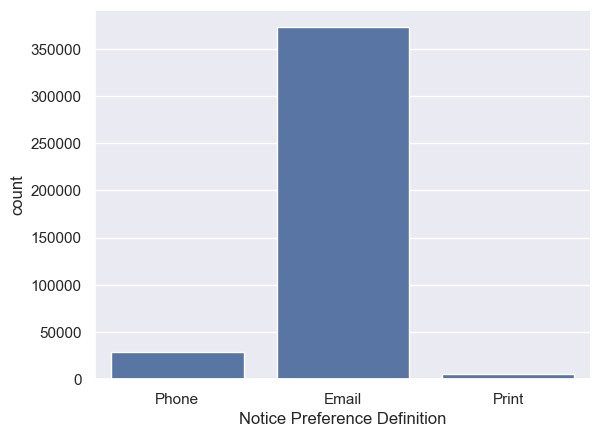

In [278]:
sns.countplot(x='Notice Preference Definition', data=df)

<Axes: xlabel='Notice Preference Definition', ylabel='percent'>

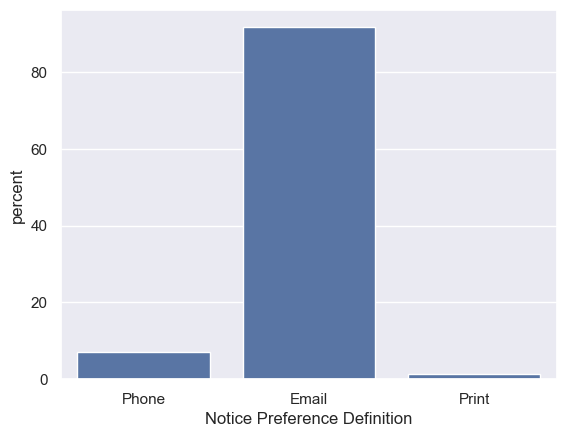

In [279]:
sns.countplot(x='Notice Preference Definition', data=df, stat='percent')

## Wie alt sind diese Nutzer durchschnittlich im Vergleich zu Nutzern, die per Post informiert werden möchten?

## Wie viele Ausleihen werden im Mittel pro Altersgruppe und pro Jahr getätigt? Ist die Streuung zwischen den Gruppen gleich?

In [362]:
mean_checkouts_ar = df.groupby(['Age Range'])['Total Checkouts'].mean()
df_mean_checkouts_ar = pd.DataFrame(mean_checkouts_ar)
df_mean_checkouts_ar

,Total Checkouts
Age Range,
0 to 9 years,99.827699
10 to 19 years,228.557776
20 to 24 years,188.340282
25 to 34 years,51.711548
35 to 44 years,76.132091
45 to 54 years,180.479764
55 to 59 years,262.142198
60 to 64 years,302.792322
65 to 74 years,368.641178


<Axes: ylabel='count'>

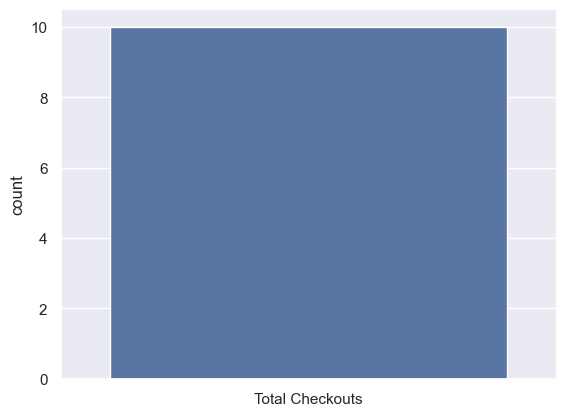

In [370]:
sns.countplot(data=df_mean_checkouts_ar)